# M3A5 - Detecção de objetos

Na prática de hoje vamos utilizar um modelo pré-treinado para detecção de objetos. Para a prática de hoje iremos utilizar a biblioteca  [Ultralytics](https://docs.ultralytics.com/).

Esse notebook está estruturado da seguinte forma.

- Introdução
- Detecção de Objetos
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [10]:
!pip install ultralytics

Defaulting to user installation because normal site-packages is not writeable


Importar as bibliotecas e Ler Imagens do Disco

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision
import ultralytics


In [12]:
image = cv2.imread("../assets/modulo3/street.jpeg")

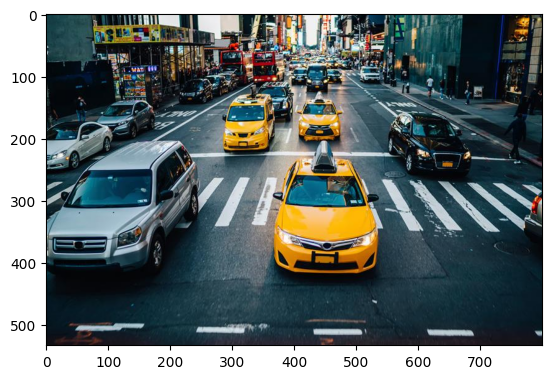

In [13]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

## Detecção de Objetos

Iremos carregar o modelo pré treinado e visualizar seus resultados.

In [ ]:
# Load a pretrained YOLO11n model
model = ultralytics.YOLO("../models/modulo3/yolo11n.pt")

# Roda a inferência do modelo YOLO.
results = model(image)

for i, result in enumerate(results):
    # Salva os resultados em uma imagem no disco.
    result.save(filename=f"../assets/modulo3/results_{i}.jpg")

# Carrega a imagem que acabou de ser salva para visualizarmos.
results_image = cv2.imread("../assets/modulo3/results_0.jpg")
plt.imshow(cv2.cvtColor(results_image, cv2.COLOR_BGR2RGB))

E basta isso para detectarmos objetos que a [YOLO](https://arxiv.org/pdf/1506.02640) foi treinada para detectar.

## Próximos Passos e Referências

Nas próximas práticas iremos ver outras tarefas clássicas de Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://docs.ultralytics.com/
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opicional)

- [x] Explore a biblioteca e tente rodar o modelo utilizando linha de comando e com outras opções.


image 1/1 /Users/larry/Documents/Dev/Residencia/Jupyter Notebooks/Modulo3/../assets/modulo3/street.jpeg: 448x640 7 persons, 16 cars, 1 bus, 1 truck, 1 traffic light, 31.3ms
Speed: 1.2ms preprocess, 31.3ms inference, 0.5ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /Users/larry/Documents/Dev/Residencia/Jupyter Notebooks/Modulo3/../assets/modulo3/street.jpeg: 448x640 3 cars, 29.8ms
Speed: 1.1ms preprocess, 29.8ms inference, 0.5ms postprocess per image at shape (1, 3, 448, 640)


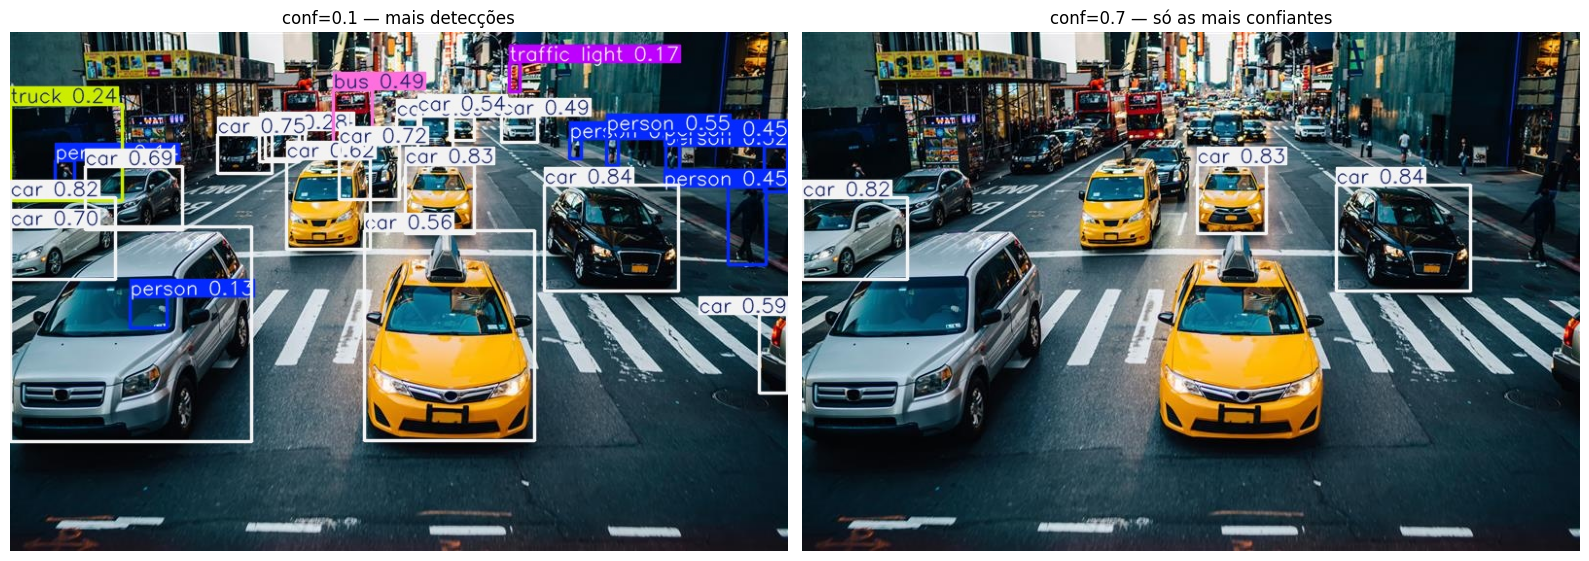

In [ ]:
#conf define o mínimo de confiança (threshold) pra uma previsão.
# quanto menor o valor, mais objetos vão aparecer, mas maior também é a chance de falsos positivos.
results_low = model("../assets/modulo3/street.jpeg", conf=0.1)
results_high = model("../assets/modulo3/street.jpeg", conf=0.8)

results_low[0].save(filename="../assets/modulo3/results_conf_low.jpg")
results_high[0].save(filename="../assets/modulo3/results_conf_high.jpg")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(cv2.cvtColor(cv2.imread("../assets/modulo3/results_conf_low.jpg"), cv2.COLOR_BGR2RGB))
axes[0].set_title("conf=0.1 — mais detecções")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(cv2.imread("../assets/modulo3/results_conf_high.jpg"), cv2.COLOR_BGR2RGB))
axes[1].set_title("conf=0.7 — só as mais confiantes")
axes[1].axis("off")
plt.tight_layout()
plt.show()